In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
ct=gpd.read_file('geometry/ct2010_3.geojson')

In [3]:
ct['tree density']=ct['tree_count']/ct['area_hectares']

In [4]:
ct['good tree density']=ct['good_tree_count']/ct['area_hectares']

In [5]:
ct['popchange10to20_binary']=np.where(ct['popchange10to20']>0,1,0)

In [6]:
print(ct.columns)

Index(['OBJECTID', 'CTLabel', 'BoroCode', 'BoroName', 'CT2010', 'BoroCT2010',
       'CDEligibil', 'NTACode', 'NTAName', 'PUMA', 'Shape__Area',
       'Shape__Length', 'population', 'pop_2020', 'popchange10to20',
       'area_km2', 'area_hectares', 'pop_growth_rate', 'pop_growth_density',
       'JoinKey', 'less than high school', 'commuting time', 'GEOID',
       'citizen ratio', 'unemployment', 'unrelated individual',
       'per capita income', 'GINI index', 'gross rent',
       '%structure early built', 'median structure year', 'facility density',
       'pop_density', 'tree_count', 'good_tree_count', 'lotarea_sum',
       'landuse_count', 'comarea_sum', 'resarea_sum', 'assesstot_sum',
       'numfloor_sum', 'bldgarea_sum', 'ComFAR', 'ResFAR', 'assesstot',
       'NumFloors', 'Avr floor area', 'building_count', 'building_height_sum',
       'avr height', 'building density', 'growth_classify', 'growth_classify2',
       'pop change type', 'geometry', 'tree density', 'good tree densi

## *Population Growth Classification*

Population change > 0 : 1

Population change<=0 : 0

In [7]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression
features_to_test = ['less than high school', 'commuting time','pop_density', 
        'citizen ratio', 'unemployment', 'unrelated individual',
        'per capita income', 'GINI index', 'gross rent',
        '%structure early built','facility density','ComFAR','ResFAR','assesstot',
        'NumFloors','Avr floor area','avr height','building density','tree density','good tree density']
target = 'popchange10to20_binary'
ct=ct.dropna()

# Create and fit a feature selector
selector = SelectKBest(f_regression, k=11)
selector.fit(ct[features_to_test].to_numpy(), ct[[target]].to_numpy().ravel())
# Get columns to keep and create new dataframe with those only
cols_idxs = selector.get_support(indices=True)
temp_df = ct[features_to_test].iloc[:,cols_idxs]
features_selected = temp_df.columns
print(features_selected)

Index(['less than high school', 'pop_density', 'citizen ratio', 'unemployment',
       'unrelated individual', 'GINI index', 'gross rent', 'assesstot',
       'building density', 'tree density', 'good tree density'],
      dtype='object')


##### Random Forest Classification

In [8]:
from sklearn.model_selection import train_test_split
features_selected = ['less than high school', 'pop_density', 'citizen ratio', 'unemployment',
        'unrelated individual', 'GINI index', 'gross rent', 'assesstot','ResFAR',
        'building density', 'tree density', 'good tree density','per capita income']
target = 'popchange10to20'
ct_test = ct.dropna()
X_data = ct_test[features_selected]
y_data = ct_test[target]

In [9]:
from imblearn.over_sampling import SMOTE
y_data_binary = (y_data > 0).astype(int)
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data_binary, test_size=0.4, random_state=42)

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [10]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=500, max_depth=8, random_state=42,class_weight={0: 1.5, 1: 1})
clf.fit(X_train_resampled, y_train_resampled)

from sklearn.metrics import classification_report, accuracy_score
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6967213114754098
              precision    recall  f1-score   support

           0       0.43      0.59      0.49       215
           1       0.84      0.73      0.78       639

    accuracy                           0.70       854
   macro avg       0.63      0.66      0.64       854
weighted avg       0.74      0.70      0.71       854



In [11]:
from sklearn.model_selection import train_test_split
features_selected = ['less than high school', 'pop_density', 'citizen ratio', 'unemployment',
        'unrelated individual', 'GINI index', 'gross rent', 'assesstot','ResFAR',
        'building density', 'tree density', 'good tree density','per capita income']
target = 'popchange10to20_binary'
ct_test = ct.dropna()
X_data = ct_test[features_selected]
y_data = ct_test[target]
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.4, random_state=42)
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1281, 13)
y_train shape: (1281,)
X_test shape: (854, 13)
y_test shape: (854,)


In [12]:
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [13]:
from collections import Counter

print("Before SMOTE:", Counter(y_train))
print("After SMOTE:", Counter(y_train_resampled))

Before SMOTE: Counter({1: 952, 0: 329})
After SMOTE: Counter({1: 952, 0: 952})


In [14]:
df_before = pd.DataFrame(X_train, columns=['building density', 'pop_density'])
df_before['label'] = y_train

df_after = pd.DataFrame(X_train_resampled, columns=['building density', 'pop_density'])
df_after['label'] = y_train_resampled

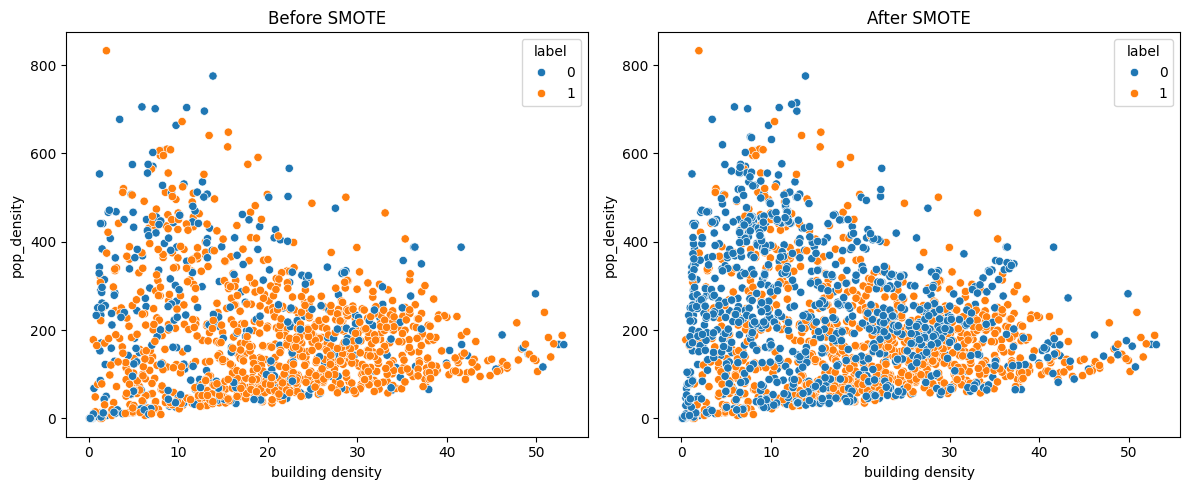

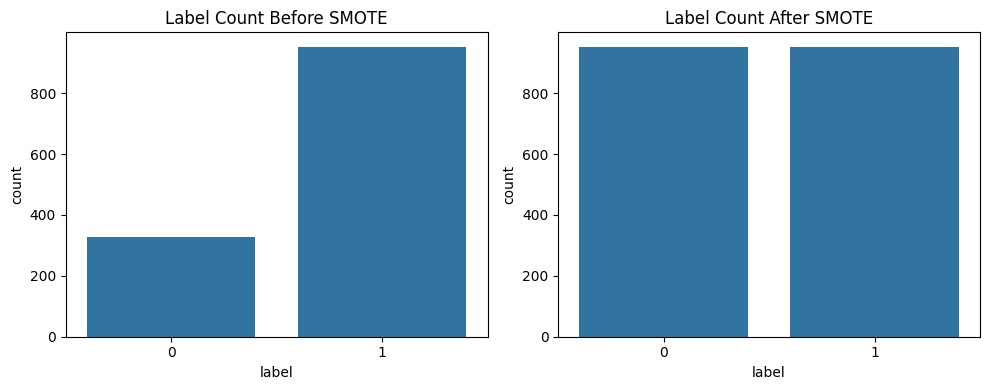

In [15]:
import seaborn as sns
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(data=df_before, x='building density', y='pop_density', hue='label', ax=axs[0])
axs[0].set_title("Before SMOTE")

sns.scatterplot(data=df_after, x='building density', y='pop_density', hue='label', ax=axs[1])
axs[1].set_title("After SMOTE")

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

sns.countplot(x='label', data=df_before, ax=axs[0])
axs[0].set_title("Label Count Before SMOTE")

sns.countplot(x='label', data=df_after, ax=axs[1])
axs[1].set_title("Label Count After SMOTE")

plt.tight_layout()
plt.show()

##### KNN

In [16]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=6)
knn.fit(X_train_resampled, y_train_resampled)

# To evaluate the model we need to make predictions for our test data
y_pred = knn.predict(X_test)
print("Test set predictions:\n", y_pred)
print("Actual values:\n", y_test)
# Based on that we can calculate the accuracy of our model
print("Test set score: ", knn.score(X_test, y_test))

from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,y_pred))

Test set predictions:
 [0 0 0 1 0 0 0 0 1 0 1 1 0 1 0 0 0 1 0 0 0 0 1 1 1 0 1 0 1 1 0 0 0 1 1 1 1
 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 1 1 0 1 0 0 1 0 0 0 1 1 1 1 1 0 0 0 0 1 1
 0 1 1 1 1 0 0 1 1 0 1 0 0 0 0 1 1 1 0 1 1 1 0 0 1 0 1 0 1 0 1 0 0 1 0 0 1
 0 0 0 1 0 1 0 0 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 0 0 0 0 1 1 1 0 0 1 0 0 1 0
 1 1 0 0 1 1 1 1 0 1 0 1 0 0 1 0 0 0 1 1 0 1 1 1 1 0 1 1 1 1 0 1 1 1 0 0 1
 1 1 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 1 0 0 0 1 0 0 1 0 0 1 0 1 1 0 0 0 1
 0 1 0 0 1 0 1 0 1 0 0 0 1 0 1 1 0 1 1 0 0 1 1 1 1 1 0 1 1 0 0 1 0 0 0 0 1
 0 0 1 0 0 1 1 0 0 1 0 0 1 0 0 1 0 0 1 1 1 1 1 0 1 0 1 1 0 1 1 0 1 0 0 0 1
 1 0 1 1 1 0 1 0 1 0 1 0 1 1 1 1 0 0 1 0 1 1 0 0 1 0 0 1 1 0 0 0 0 0 1 1 1
 1 0 0 1 1 0 0 1 1 1 0 1 1 1 0 1 1 0 0 1 1 1 0 0 1 0 1 1 1 0 1 1 0 0 0 1 0
 1 1 0 1 0 0 1 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 1 1 1 0 0 0 1 0 0
 1 0 0 0 0 1 0 1 0 1 1 1 0 1 0 0 0 0 0 1 1 0 1 1 0 1 1 1 1 0 0 1 0 1 0 1 0
 0 1 1 0 0 0 0 1 1 1 1 0 0 1 1 1 0 0 1 1 0 1 1 1 1 1 0 1 1 1 0 0 1 0 0 1 1
 0

##### Decision Tree

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_squared_error
tree = DecisionTreeClassifier(max_depth=3,class_weight={0: 1.5, 1: 1}).fit(X_train_resampled, y_train_resampled)

# Compare the train and test scores (higher is better fit)
print("Accuracy on training set: {:.3f}".format(tree.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(tree.score(X_test, y_test)))

Accuracy on training set: 0.418
Accuracy on test set: 0.402


##### Random Forest Classification

In [18]:
from sklearn.ensemble import RandomForestClassifier
forest = RandomForestClassifier(n_estimators=50, max_depth=6)
forest.fit(X_train_resampled, y_train_resampled)

# Compare the train and test scores (higher is better fit)
print("Accuracy on training set: {:.3f}".format(forest.score(X_train_resampled, y_train_resampled)))
print("Accuracy on test set: {:.3f}".format(forest.score(X_test, y_test)))

# Display the feature importance measures
display(pd.DataFrame(zip(features_selected, forest.feature_importances_)))

Accuracy on training set: 0.808
Accuracy on test set: 0.747


,0,1
0,less than high school,0.101608
1,pop_density,0.121944
2,citizen ratio,0.085696
3,unemployment,0.061571
4,unrelated individual,0.074774
5,GINI index,0.037515
6,gross rent,0.079343
7,assesstot,0.123361
8,ResFAR,0.054994
9,building density,0.111638


In [19]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

from statsmodels.tools.tools import add_constant
X_with_const = add_constant(X_data)

vif_df = pd.DataFrame()
vif_df["feature"] = X_data.columns
vif_df["VIF"] = [variance_inflation_factor(X_with_const.values, i+1) for i in range(X_data.shape[1])]
print(vif_df.sort_values("VIF", ascending=False))


                  feature       VIF
10           tree density  4.008047
11      good tree density  3.481904
12      per capita income  3.119311
0   less than high school  2.587067
6              gross rent  2.301673
4    unrelated individual  1.777459
1             pop_density  1.672700
5              GINI index  1.649698
2           citizen ratio  1.581061
9        building density  1.497040
3            unemployment  1.298794
8                  ResFAR  1.140921
7               assesstot  1.085905


##### SVM

In [20]:
features_selected = ['less than high school', 'pop_density', 'citizen ratio', 'unemployment',
        'unrelated individual', 'GINI index', 'gross rent', 'assesstot','ResFAR',
        'building density', 'tree density', 'good tree density','per capita income']

X = ct[features_selected]
y = ct['popchange10to20_binary'] 
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.4, random_state=42)

In [21]:
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [22]:
from sklearn.svm import SVC
svc = SVC(kernel="poly",class_weight={0: 1.5, 1: 1}).fit(X_train_resampled, y_train_resampled)

# Compare the train and test scores (higher is better fit)
print("Accuracy on training set: {:.3f}".format(svc.score(X_train_resampled, y_train_resampled)))
print("Accuracy on training set: {:.3f}".format(svc.score(X_test, y_test)))

# Let's also get more information on performance using a confusion matrix
print("Confusion Matrix")
print(confusion_matrix(y_test,svc.predict(X_test)))

Accuracy on training set: 0.724
Accuracy on training set: 0.591
Confusion Matrix
[[148  67]
 [282 357]]


In [23]:
svc = SVC(kernel="linear",class_weight={0: 1.5, 1: 1}).fit(X_train_resampled, y_train_resampled)

# Compare the train and test scores (higher is better fit)
print("Accuracy on training set: {:.3f}".format(svc.score(X_train_resampled, y_train_resampled)))
print("Accuracy on training set: {:.3f}".format(svc.score(X_test, y_test)))

# Let's also get more information on performance using a confusion matrix
print("Confusion Matrix")
print(confusion_matrix(y_test,svc.predict(X_test)))

Accuracy on training set: 0.644
Accuracy on training set: 0.552
Confusion Matrix
[[159  56]
 [327 312]]


In [24]:
svc = SVC(kernel="rbf",probability=True,C=1.0,class_weight={0: 1.5, 1: 1}).fit(X_train_resampled, y_train_resampled)

# Compare the train and test scores (higher is better fit)
print("Accuracy on training set: {:.3f}".format(svc.score(X_train_resampled, y_train_resampled)))
print("Accuracy on training set: {:.3f}".format(svc.score(X_test, y_test)))

# Let's also get more information on performance using a confusion matrix
print("Confusion Matrix")
print(confusion_matrix(y_test,svc.predict(X_test)))

Accuracy on training set: 0.763
Accuracy on training set: 0.651
Confusion Matrix
[[146  69]
 [229 410]]


In [25]:
from joblib import dump, load

In [26]:
# dump(forest, 'predictive model/random_forest_growth.pkl')
# dump(svc, 'predictive model/svc_growth.pkl')

## *Classification of Population Growth Levels*

Population change rate <= -0.038 : 0

Population change rate >= 0.06 : 2

-0.038 < Population change rate < 0.06 : 1

In [27]:
features_to_test = ['less than high school', 'commuting time','pop_density', 
        'citizen ratio', 'unemployment', 'unrelated individual',
        'per capita income', 'GINI index', 'gross rent',
        '%structure early built','facility density','ComFAR','ResFAR','assesstot',
        'NumFloors','Avr floor area','avr height','building density','tree density','good tree density']
target = 'growth_classify2'
ct=ct.dropna()

# Create and fit a feature selector
selector = SelectKBest(f_regression, k=11)
selector.fit(ct[features_to_test].to_numpy(), ct[[target]].to_numpy().ravel())
# Get columns to keep and create new dataframe with those only
cols_idxs = selector.get_support(indices=True)
temp_df = ct[features_to_test].iloc[:,cols_idxs]
features_selected = temp_df.columns
print(features_selected)

Index(['less than high school', 'pop_density', 'citizen ratio', 'unemployment',
       'unrelated individual', 'gross rent', 'ComFAR', 'assesstot',
       'Avr floor area', 'building density', 'good tree density'],
      dtype='object')


In [28]:
from sklearn.model_selection import train_test_split
features_selected = ['less than high school', 'pop_density', 'citizen ratio', 'unemployment',
        'unrelated individual', 'GINI index', 'gross rent', 'assesstot','ComFAR',
        'building density', 'Avr floor area', 'good tree density','per capita income']
target = 'growth_classify2'
ct_test = ct.dropna()
X_data = ct_test[features_selected]
y_data = ct_test[target]
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.4, random_state=42)
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1281, 13)
y_train shape: (1281,)
X_test shape: (854, 13)
y_test shape: (854,)


In [29]:
category_counts = ct['growth_classify2'].value_counts().sort_index()
print(category_counts)

growth_classify2
0     312
1     792
2    1031
Name: count, dtype: int64


In [30]:
sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train, y_train)

In [31]:
df_before = pd.DataFrame(X_train, columns=['building density', 'pop_density'])
df_before['label'] = y_train

df_after = pd.DataFrame(X_train_resampled, columns=['building density', 'pop_density'])
df_after['label'] = y_train_resampled

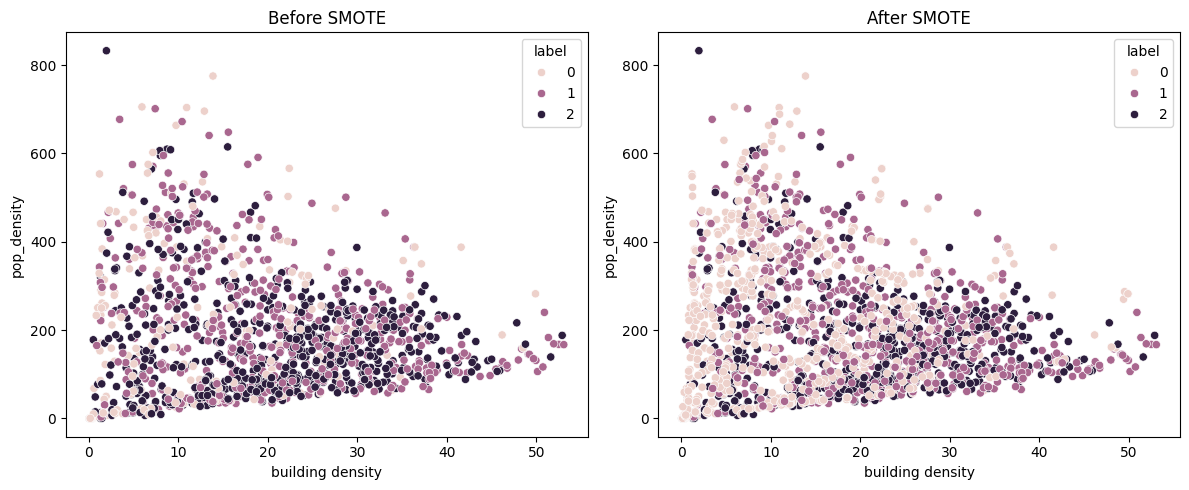

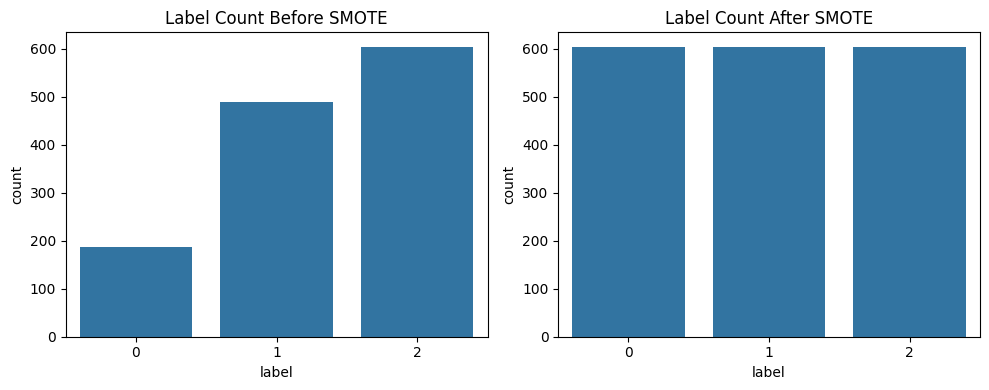

In [32]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(data=df_before, x='building density', y='pop_density', hue='label', ax=axs[0])
axs[0].set_title("Before SMOTE")

sns.scatterplot(data=df_after, x='building density', y='pop_density', hue='label', ax=axs[1])
axs[1].set_title("After SMOTE")

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

sns.countplot(x='label', data=df_before, ax=axs[0])
axs[0].set_title("Label Count Before SMOTE")

sns.countplot(x='label', data=df_after, ax=axs[1])
axs[1].set_title("Label Count After SMOTE")

plt.tight_layout()
plt.show()

##### KNN

In [33]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=6)
knn.fit(X_train_resampled, y_train_resampled)

# To evaluate the model we need to make predictions for our test data
y_pred = knn.predict(X_test)
print("Test set predictions:\n", y_pred)
print("Actual values:\n", y_test)
# Based on that we can calculate the accuracy of our model
print("Test set score: ", knn.score(X_test, y_test))
print("Train set score: ", knn.score(X_train_resampled, y_train_resampled))

from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,y_pred))

Test set predictions:
 [0 0 0 2 1 0 0 0 2 0 0 2 2 1 1 2 0 2 2 1 0 2 2 1 1 0 2 1 1 2 1 0 0 0 2 1 2
 1 0 1 0 0 2 2 0 1 2 0 1 1 0 1 0 1 1 2 1 0 0 1 0 0 1 2 0 1 1 0 0 0 0 1 2 2
 0 1 2 2 1 1 0 2 2 2 1 0 1 0 1 2 1 0 0 1 1 2 2 0 0 0 2 0 2 0 1 1 0 2 0 0 1
 2 0 1 2 1 1 0 1 1 0 2 0 1 2 1 0 2 1 1 1 1 2 2 1 1 1 0 1 2 1 0 0 1 0 1 1 0
 2 1 0 1 1 0 0 0 1 1 0 2 0 0 1 1 2 0 1 0 0 1 2 2 1 1 1 1 1 2 1 2 1 2 1 1 2
 1 0 1 0 0 1 1 0 1 2 0 0 1 0 0 1 0 2 1 1 0 1 0 2 0 1 0 0 0 2 1 1 1 0 0 0 2
 1 2 1 0 1 0 2 1 1 0 1 2 1 1 2 1 1 2 2 0 1 1 1 2 2 2 2 1 2 0 2 1 2 1 0 0 1
 0 2 2 1 0 2 1 0 1 1 0 0 2 1 0 1 2 0 0 2 2 2 2 0 1 2 2 2 0 2 2 0 1 0 1 0 2
 1 0 2 1 1 0 2 0 1 0 1 0 2 0 2 2 0 0 2 1 1 1 1 2 2 1 0 2 2 2 0 0 1 0 2 1 2
 1 0 0 0 2 0 0 0 2 0 0 1 2 2 2 1 1 0 0 2 1 1 1 0 1 1 1 1 0 0 1 2 0 0 2 1 2
 0 2 1 1 1 0 1 2 0 1 1 1 0 2 1 2 1 0 0 0 1 0 1 0 2 0 0 1 1 1 1 1 2 0 2 0 0
 0 1 1 1 0 2 0 1 0 0 2 2 0 2 0 1 0 2 0 0 2 0 2 2 0 2 2 2 2 0 2 1 1 2 0 2 1
 1 0 1 0 0 1 0 1 1 2 2 0 0 2 2 1 2 0 2 2 1 1 2 0 2 2 1 2 2 1 2 1 2 0 0 2 1
 0

##### Decision Tree

In [34]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_squared_error
tree = DecisionTreeClassifier(max_depth=3).fit(X_train_resampled, y_train_resampled)

# Compare the train and test scores (higher is better fit)
print("Accuracy on training set: {:.3f}".format(tree.score(X_train_resampled, y_train_resampled)))
print("Accuracy on test set: {:.3f}".format(tree.score(X_test, y_test)))

Accuracy on training set: 0.491
Accuracy on test set: 0.506


##### Random Forest Classifier

In [35]:
from sklearn.ensemble import RandomForestClassifier
forest = RandomForestClassifier(n_estimators=300, max_depth=6,class_weight = {0: 1.5, 1: 2, 2: 2})
forest.fit(X_train_resampled, y_train_resampled)

# Compare the train and test scores (higher is better fit)
print("Accuracy on training set: {:.3f}".format(forest.score(X_train_resampled, y_train_resampled)))
print("Accuracy on test set: {:.3f}".format(forest.score(X_test, y_test)))

# Display the feature importance measures
display(pd.DataFrame(zip(features_selected, forest.feature_importances_)))
y_pred=forest.predict(X_test)

Accuracy on training set: 0.724
Accuracy on test set: 0.513


,0,1
0,less than high school,0.088710
1,pop_density,0.103732
2,citizen ratio,0.068653
3,unemployment,0.055565
4,unrelated individual,0.057023
5,GINI index,0.044305
6,gross rent,0.045586
7,assesstot,0.123792
8,ComFAR,0.080598
9,building density,0.119958


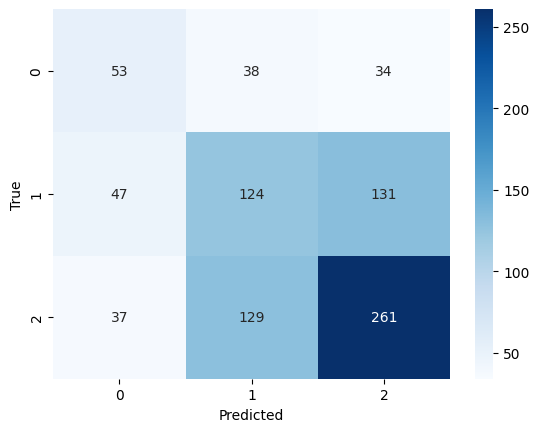

In [36]:
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [37]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.39      0.42      0.40       125
           1       0.43      0.41      0.42       302
           2       0.61      0.61      0.61       427

    accuracy                           0.51       854
   macro avg       0.48      0.48      0.48       854
weighted avg       0.51      0.51      0.51       854



##### SVM

In [38]:
features_selected = ['less than high school', 'pop_density', 'citizen ratio', 'unemployment',
        'unrelated individual', 'GINI index', 'gross rent', 'assesstot','ResFAR',
        'building density', 'tree density', 'good tree density','per capita income']

X = ct[features_selected]
y = ct['growth_classify2'] 
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.4, random_state=42)

In [39]:
sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train, y_train)

In [40]:
svc = SVC(kernel="rbf").fit(X_train_resampled, y_train_resampled)

# Compare the train and test scores (higher is better fit)
print("Accuracy on training set: {:.3f}".format(svc.score(X_train_resampled, y_train_resampled)))
print("Accuracy on training set: {:.3f}".format(svc.score(X_test, y_test)))

# Let's also get more information on performance using a confusion matrix
print("Confusion Matrix")
print(confusion_matrix(y_test,svc.predict(X_test)))

Accuracy on training set: 0.623
Accuracy on training set: 0.504
Confusion Matrix
[[ 69  34  22]
 [ 72 126 104]
 [ 73 119 235]]


In [41]:
# dump(forest,'predictive model/forest_growth_type.pkl')

In [42]:
svc = SVC(kernel="poly").fit(X_train_resampled, y_train_resampled)

# Compare the train and test scores (higher is better fit)
print("Accuracy on training set: {:.3f}".format(svc.score(X_train_resampled, y_train_resampled)))
print("Accuracy on training set: {:.3f}".format(svc.score(X_test, y_test)))

# Let's also get more information on performance using a confusion matrix
print("Confusion Matrix (Polynomial)")
print(confusion_matrix(y_test,svc.predict(X_test)))

Accuracy on training set: 0.603
Accuracy on training set: 0.532
Confusion Matrix (Polynomial)
[[ 49  19  57]
 [ 51  80 171]
 [ 36  66 325]]


In [43]:
svc = SVC(kernel="linear").fit(X_train_resampled, y_train_resampled)

# Compare the train and test scores (higher is better fit)
print("Accuracy on training set: {:.3f}".format(svc.score(X_train_resampled, y_train_resampled)))
print("Accuracy on training set: {:.3f}".format(svc.score(X_test, y_test)))

# Let's also get more information on performance using a confusion matrix
print("Confusion Matrix (Polynomial)")
print(confusion_matrix(y_test,svc.predict(X_test)))

Accuracy on training set: 0.536
Accuracy on training set: 0.444
Confusion Matrix (Polynomial)
[[ 73  27  25]
 [ 97  75 130]
 [ 98  98 231]]


In [44]:
ct.to_file('2010_final.geojson')